In [2]:
%load_ext autoreload
%autoreload 2

### Eval Losses

plot training and validation losses from training

In [1]:
import matplotlib.pyplot as plt
import json, os

In [3]:
def load_loss(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

holders = [None, None]
for ver in [6, 7]:
    file_path = f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{ver}/train_val_loss.json"
    holders[ver - 6] = load_loss(file_path)

In [8]:
# new gen of training doesn't store loss in the same way (older version is below)
i = 1
train_holder = holders[i][list(holders[i].keys())[0]]['train']
val_holder = holders[i][list(holders[i].keys())[0]]['train']
# print(holders[i])
# print(holders[i][list(holders[i].keys())[0]]['train'])
train_loss = []
clip_loss = []
loc_loss = []
id_loss = []
for train, val in zip(train_holder, val_holder):
    train_loss.append(train['total'])
    clip_loss.append(train['clip'])
    loc_loss.append(train['loc'])
    id_loss.append(train['id'])

print(train_loss)

[5.161538889272839, 2.8644410644693576, 2.441524907392813, 2.2244213074741634, 2.0904081522657516, 1.9944635714453163, 1.9231732949128388, 1.8686087494961758, 1.8238370313881136, 1.7850075827253626, 1.7536230822911498, 1.7240631742511234, 1.6983699690281078, 1.6747063590702436, 1.6505372281446524, 1.6298027608496077, 1.6107173019140324, 1.5919875739990397, 1.576411737321962, 1.561802129711665, 1.5482125598910852, 1.5315501179424584, 1.5171590800868704, 1.505566145743884, 1.489293741613415, 1.4794483797854565, 1.4681826130887294, 1.457011421978051, 1.4471888234387054, 1.4362813621294415, 1.4273665118428833, 1.4190003801491244, 1.4098482030165111, 1.4017388645511992, 1.3951039360854642, 1.3860982258184582, 1.3784589894866266, 1.3691599463697866, 1.3632751537003416, 1.356679447403191, 1.350765973329544, 1.3422075365621147, 1.3357222382777125, 1.3294415465821612, 1.3224716936823324, 1.3168129921593565, 1.3106873948903794, 1.3040940346193652, 1.2972630008273092, 1.2928462396868576]


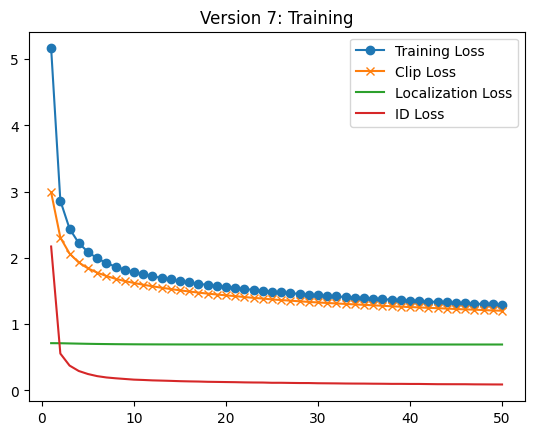

In [9]:
ver = [6, 7][i]
epochs = range(1, len(train_loss) + 1)
plt.title(f'Version {ver}: Training')
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, clip_loss, label='Clip Loss', marker='x')
plt.plot(epochs, loc_loss, label='Localization Loss')
plt.plot(epochs, id_loss, label='ID Loss')
plt.legend()
plt.show()

TypeError: unhashable type: 'dict'

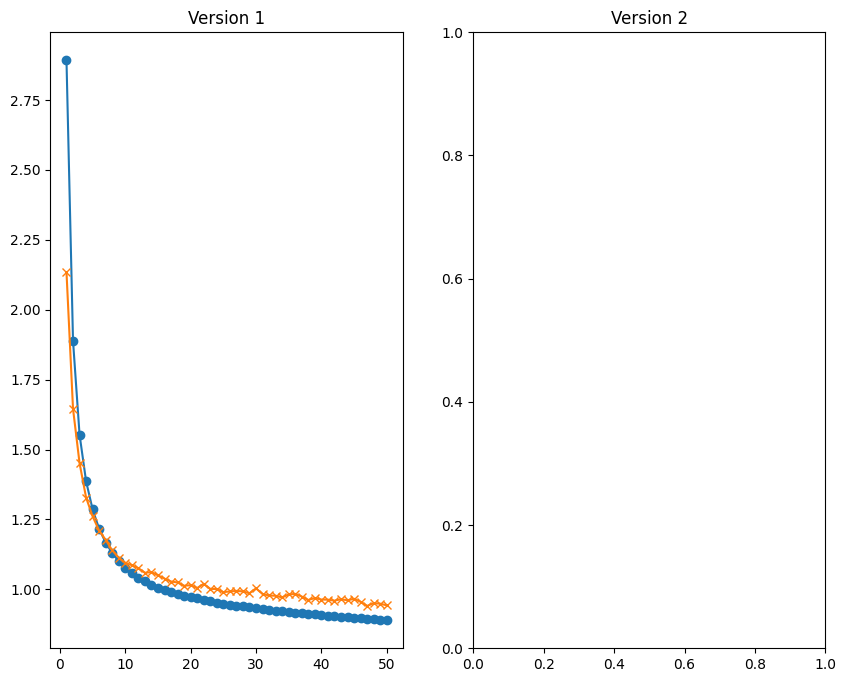

In [6]:
epochs = range(1, len(holders[0][list(holders[0].keys())[0]]['train']) + 1)
fig, axs = plt.subplots(ncols=2, figsize=(10, 8))

def set_ax(ax, version, loss):
    epochs = range(1, len(loss[list(loss.keys())[0]]['train']) + 1)
    ax.set_title(f'Version {version}')
    ax.plot(epochs, loss[list(loss.keys())[0]]['train'], label='Training loss', marker='o')
    # Plot validation loss
    ax.plot(epochs, loss[list(loss.keys())[0]]['val'], label='Validation loss', marker='x')

set_ax(axs[0], 1, holders[0])
set_ax(axs[1], 2, holders[1])

plt.show()

In [17]:
loss_range = []
for holder in holders:
    tloss = holder[list(holder.keys())[0]]['train']
    diff = max(tloss) - min(tloss)
    print(f"{max(tloss)} - {min(tloss)} --> {diff}")
    loss_range.append(diff)

2.8770269538132345 - 0.9833286508091054 --> 1.893698303004129
2.898617761533011 - 0.9193038401129471 --> 1.9793139214200641
2.8946523597933655 - 0.9397208977410748 --> 1.9549314620522908
2.8918259175704724 - 0.889604765156093 --> 2.0022211524143794


#### Misc.

In [1]:
## quickly check the storage mode of subcell embeddings
import torch 

data = torch.load('/scratch/users/samutiti/U54/embeddings/all_harmonized_features_microscope_vit.pth', weights_only=False)

In [3]:
print(type(data))
print(type(data[0]))
print(type(data[1]))

<class 'tuple'>
<class 'pandas.DataFrame'>
<class 'torch.Tensor'>


In [5]:
print(data[1].shape)

torch.Size([1138378, 1536])


### Eval inference outputs

evaluate embeddings / set up for PCA and Umapping

In [5]:
!pip install scanpy

  Obtaining dependency information for scanpy from https://files.pythonhosted.org/packages/44/f0/000ac705a3d5b8744c6eabfce6b413b131829542ffec05020b1e931ffed4/scanpy-1.12-py3-none-any.whl.metadata
  Using cached scanpy-1.12-py3-none-any.whl.metadata (8.4 kB)
  Obtaining dependency information for fast-array-utils[accel,sparse]>=1.2.1 from https://files.pythonhosted.org/packages/5f/cb/ddcf4ad63ba88df95025837e35faf6ea6862bab1327f836801ba02140a22/fast_array_utils-1.3.1-py3-none-any.whl.metadata
  Using cached fast_array_utils-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Obtaining dependency information for numba>=0.60 from https://files.pythonhosted.org/packages/9b/89/1a74ea99b180b7a5587b0301ed1b183a2937c4b4b67f7994689b5d36fc34/numba-0.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Using cached numba-0.64.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Obtaining dependency information for patsy from https://files.pythonhosted.org/p

In [10]:
import anndata as ad 

training_v = 5
embeddings = ad.read_h5ad(f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{training_v}/inference.h5ad")

In [ ]:
print(embeddings)
adata = embeddings

# print(adata.obs['locations'])

AnnData object with n_obs × n_vars = 1128034 × 1280
    obs: 'gene_name', 'gene_idx', 'locations'
    obsm: 'h'
0                       Golgi apparatus
1                       Golgi apparatus
2                       Golgi apparatus
3                       Golgi apparatus
4                       Golgi apparatus
                       ...             
1128029    Nuclear membrane,Nucleoplasm
1128030    Nuclear membrane,Nucleoplasm
1128031    Nuclear membrane,Nucleoplasm
1128032    Nuclear membrane,Nucleoplasm
1128033    Nuclear membrane,Nucleoplasm
Name: locations, Length: 1128034, dtype: category
Categories (853, object): ['', 'Actin filaments', 'Actin filaments,Cell Junctions', 'Actin filaments,Cell Junctions,Plasma membrane', ..., 'Plasma membrane,Vesicles', 'Rods & Rings', 'Rods & Rings,Vesicles', 'Vesicles']


In [13]:
import scanpy as sc

NUM_PCS = 50
LEI_RES = 0.3

sc.pp.pca(
        adata,
        n_comps=NUM_PCS,
        svd_solver="arpack"
    )
print('pca complete')

sc.pp.neighbors(
        adata,
        n_neighbors=30,
        n_pcs=NUM_PCS,
    )
print('nieghbors complete')

sc.tl.leiden(
        adata,
        resolution=LEI_RES,
        key_added=f'leiden_{LEI_RES}'
    )
print('leiden complete')

sc.tl.umap(
        adata,
        min_dist=0.1,
    )

print('umap complete')

adata.obs["umap_x"] = adata.obsm["X_umap"][:, 0]
adata.obs["umap_y"] = adata.obsm["X_umap"][:, 1]

### Visualize Umap
sc.pl.umap(
        adata,
        color=[f"leiden_{LEI_RES}"],
        show=False,
        save=f"_training_V0{training_v}_mlp_embed.png"
    )


pca complete
nieghbors complete


/tmp/ipykernel_32219/798167704.py:20: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(
/scratch/users/samutiti/U54/env/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/scratch/users/samutiti/U54/env/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/scratch/users/samutiti/U54/env/lib/python3.12/site-packages/leidenalg/Optim

: 

: 

: 

### Generate UMAPs

In [1]:
import anndata as ad
import seaborn as sns

In [ ]:
train_v = 5
adata_path = f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{train_v}/inference_analyzed.h5ad"
adata = ad.read_h5ad(adata_path)
print(adata)

In [ ]:
sns.scatterplot(
    data=adata.obs,
    x="umap_x",
    y="umap_y",
    hue="locations",
    s=5,
    alpha=0.8
)

In [2]:
check_adata = ad.read_h5ad("/scratch/users/samutiti/U54/embeddings/all_harmonized_features_microscope_vit.h5ad")
print(check_adata)

AnnData object with n_obs × n_vars = 1138378 × 1536
    obs: 'cell_id', 'if_plate_id', 'position', 'sample', 'atlas_name', 'antibody', 'ensembl_ids', 'gene_names', 'locations', 'cell_path', 'Time (ms)'


In [3]:
print(check_adata.obs['atlas_name'])

0           U2OS
1           U2OS
2           U2OS
3           U2OS
4           U2OS
           ...  
1138373    A-431
1138374    A-431
1138375    A-431
1138376    A-431
1138377    A-431
Name: atlas_name, Length: 1138378, dtype: category
Categories (37, object): ['A-431', 'A-549', 'AF22', 'ASC52telo', ..., 'U-251MG', 'hTCEpi', 'hTERT-RPE1', 'hTERT-RPE1 (serum starved)']
